# 03. Learning under Uncertainty

## 📚 Learning Objectives

By completing this notebook, you will:
- Apply probability, Bayes, and decision theory
- Model uncertainty in inference and learning

## 🔗 Where this fits

**Builds on:** Course 01 (AIAT 111) — Unit 2, lesson 04 "Probabilistic Reasoning: Bayes' Theorem" — the same prior/likelihood/posterior update, now driving decisions.

**Used later in:** Course 03 (AIAT 113) — Unit 5, which formalises the probability, sampling and inference used informally here.

---


# 03. Learning under Uncertainty

---

## The Story: Dealing with Uncertainty in Real Life

**THE PROBLEM**: In real life, we rarely have complete information! When a doctor diagnoses a disease, they don't know FOR CERTAIN if the patient has it - they work with probabilities.

**BEFORE**: We make decisions based on guesswork or ignore uncertainty.
**AFTER**: We use probability and Bayesian reasoning to make informed decisions even when we don't have complete information!

---

## ❌ THE PROBLEM: Why Uncertainty Matters

**Problem 1**: We need to make decisions without complete information
- Medical diagnosis: Test might be wrong
- Weather prediction: Can't know for sure
- Business decisions: Future is uncertain

**Problem 2**: Without probability, we either:
- Ignore uncertainty (make bad decisions)
- Be paralyzed by uncertainty (can't decide)

**WHY IT MATTERS**: Bad decisions in uncertain situations can be costly or dangerous!

---

## ✅ THE SOLUTION: Probability and Bayesian Reasoning

**Solution**: Use mathematics of probability to:
1. **Quantify uncertainty**: Express what we don't know as probabilities
2. **Update beliefs**: When we get new evidence, update our beliefs using Bayes' theorem
3. **Make optimal decisions**: Use expected utility to make the best decision

**HOW IT SOLVES IT**:
- ✅ Instead of ignoring uncertainty, we measure it
- ✅ Instead of guessing, we calculate probabilities
- ✅ Instead of being paralyzed, we make informed decisions

## Learning Objectives
1. Understand the PROBLEM of uncertainty
2. Learn the SOLUTION: probability and Bayesian inference
3. See HOW it solves real-world problems
4. Compare BEFORE (guesswork) vs AFTER (probabilistic reasoning)


## 🌍 The case: the same number, read two ways

**The doctors.** Gigerenzer & Edwards, *Simple tools for understanding risks: from innumeracy to insight*, **BMJ 327, 741–744 (2003)**. Forty-eight physicians — average **14 years** of professional experience — were given the standard mammography screening figures and asked a single question: a woman's screening result is positive; what is the chance she has breast cancer? Phrased as conditional probabilities (prevalence, sensitivity, false-positive rate), **their answers ranged from 1% to 90%**, and very few gave the correct answer of **about 8%**. Given the *same* information as natural frequencies — "out of every 1,000 women…" — most got it right or close.

The arithmetic was never the difficulty. The framing was, and these were doctors delivering the result to a frightened patient that afternoon.

**The courtroom.** England, 1999: Sally Clark was convicted of murdering her two infant sons. The paediatrician Roy Meadow told the jury that the chance of two cot deaths in a family like hers was **1 in 73 million** — a figure obtained by squaring a single-death estimate of roughly 1 in 8,500, which silently assumes the two deaths are independent events. The **Royal Statistical Society issued a public statement in October 2001** saying there was no statistical basis for that calculation. Her conviction was quashed on a second appeal in **2003**; the Court of Appeal indicated it would probably have allowed the appeal on the statistical evidence alone.

Nothing went wrong with the multiplication. What went wrong was an unchecked independence assumption, and a conditional probability read backwards — as though "how unlikely is this evidence if she is innocent" answered "how likely is it that she is innocent".

### What goes wrong without this

The cell below prints the two answers people actually give when a test comes back positive: *"I definitely have it"* (panic) and *"tests are unreliable, ignore it"* (dangerous). Both are decisions, and both are wrong.

In Part 3 you will compute the real answer for a test that is 99% accurate on sick people, produces 5% false alarms, and screens a population where 1% are ill: **16.7%**. A positive result on that test is **five times more likely to be a false alarm than a true case** — and none of that is visible from "99% accurate". Getting this wrong is not an academic slip; it is the difference between a biopsy and a repeat test, between a frozen bank account and a phone call, between a conviction and an acquittal.

---


## Part 1: ❌ BEFORE - The Problem of Uncertainty

**THE PROBLEM**: Let's see what happens when we ignore uncertainty or use guesswork instead of probability.

## 📥 Inputs & 📤 Outputs

**Inputs:** What we use in this notebook

- Libraries and concepts as introduced in this notebook; see prerequisites and code comments.

**Outputs:** What you'll see when you run the cells

- Printed results, figures, and summaries as shown when you run the cells.

---

In [1]:
# ❌ THE PROBLEM: Making decisions without understanding probability
# Example: Medical test result - how do we interpret it?

print("=" * 70)
print("❌ BEFORE: The Problem - Making Decisions Without Probability")
print("=" * 70)
print()
print("Scenario: A medical test comes back POSITIVE")
print("\n❌ PROBLEM 1: Without probability, people might think:")
print("   'Test is positive = I definitely have the disease!'") 
print("   → This causes unnecessary panic!")
print()
print("❌ PROBLEM 2: Or they might think:")
print("   'Test might be wrong, so I'll ignore it'") 
print("   → This causes dangerous neglect!")
print()
print("❌ PROBLEM 3: Without probability, we can't:")
print("   • Quantify how uncertain we are")
print("   • Update our beliefs with new evidence")
print("   • Make optimal decisions under uncertainty")
print()
print("🤔 WHY THIS IS A PROBLEM:")
print("   • Medical: Wrong diagnosis = wrong treatment = harm")
print("   • Business: Bad decisions = financial loss")
print("   • Safety: Ignoring uncertainty = accidents")
print()
print("💡 THE SOLUTION: Use probability to quantify and manage uncertainty!")

❌ BEFORE: The Problem - Making Decisions Without Probability

Scenario: A medical test comes back POSITIVE

❌ PROBLEM 1: Without probability, people might think:
   'Test is positive = I definitely have the disease!'
   → This causes unnecessary panic!

❌ PROBLEM 2: Or they might think:
   'Test might be wrong, so I'll ignore it'
   → This causes dangerous neglect!

❌ PROBLEM 3: Without probability, we can't:
   • Quantify how uncertain we are
   • Update our beliefs with new evidence
   • Make optimal decisions under uncertainty

🤔 WHY THIS IS A PROBLEM:
   • Medical: Wrong diagnosis = wrong treatment = harm
   • Business: Bad decisions = financial loss
   • Safety: Ignoring uncertainty = accidents

💡 THE SOLUTION: Use probability to quantify and manage uncertainty!


## Part 2: ✅ AFTER - The Solution: Probability

**THE SOLUTION**: Use probability to quantify uncertainty and make informed decisions!

In [2]:
# ✅ THE SOLUTION: Using probability to make informed decisions
# This is how probability solves the problem!

import numpy as np
import matplotlib.pyplot as plt
from collections import Counter

print("=" * 70)
print("✅ AFTER: The Solution - Using Probability")
print("=" * 70)
print()

# Example: Coin toss - simplest example of uncertainty
print("📊 Example: Coin Toss (Understanding Probability)")
print("   Problem: We don't know what side will come up")
print("   Solution: Use probability to express this uncertainty")
print()

# Fair coin: P(Heads) = 0.5, P(Tails) = 0.5
P_heads = 0.5  # Probability of heads = 50%
P_tails = 0.5  # Probability of tails = 50%

print(f"   ✅ We quantify uncertainty: P(Heads) = {P_heads} (50%)")
print(f"   ✅ We quantify uncertainty: P(Tails) = {P_tails} (50%)")
print()
print("🔗 HOW THIS SOLVES THE PROBLEM:")
print("   • Instead of 'maybe heads, maybe tails' (vague)")
print("   • We say 'P(Heads) = 0.5' (precise!)")
print("   • Now we can calculate expected values, make decisions!")
print()

# Simulate coin tosses to verify our probability
print("📊 Verifying probability through simulation:")
print("   ⏰ WHEN to use: Verify probability theory through simulation - Monte Carlo method!")
print("   💡 WHY use: Simulation proves probability works - matches theoretical predictions!")

np.random.seed(42)  # For reproducible results: Set random seed so we get same results each time (allows verification)
coin_tosses = np.random.choice(["Heads", "Tails"], size=1000, p=[0.5, 0.5])  # Simulate 1000 tosses: Generate 1000 random choices, each with 50% probability of Heads or Tails
counts = Counter(coin_tosses)  # Count outcomes: Count how many times each outcome occurred (Heads vs Tails)

print(f"   After 1000 tosses:")
print(f"   Heads: {counts['Heads']} times ({counts['Heads']/1000:.3f} = {counts['Heads']/10:.1f}%)")  # Show Heads count: Display number of Heads and percentage (count/1000 = proportion 0.503, count/10 = 50.3% since we multiply by 10 to convert decimal to percentage)
print(f"   Tails: {counts['Tails']} times ({counts['Tails']/1000:.3f} = {counts['Tails']/10:.1f}%)")  # Show Tails count: Display number of Tails and percentage (count/1000 = proportion 0.497, count/10 = 49.7%, should be close to 50% each!)
print()
print("✅ Result: Simulation matches our probability! (≈ 50% each)")  # Verify result: Should be approximately 50% each (proves probability theory works!)
print("   This proves probability works - it predicts reality!")  # Conclusion: Probability theory accurately predicts real-world outcomes!

✅ AFTER: The Solution - Using Probability

📊 Example: Coin Toss (Understanding Probability)
   Problem: We don't know what side will come up
   Solution: Use probability to express this uncertainty

   ✅ We quantify uncertainty: P(Heads) = 0.5 (50%)
   ✅ We quantify uncertainty: P(Tails) = 0.5 (50%)

🔗 HOW THIS SOLVES THE PROBLEM:
   • Instead of 'maybe heads, maybe tails' (vague)
   • We say 'P(Heads) = 0.5' (precise!)
   • Now we can calculate expected values, make decisions!

📊 Verifying probability through simulation:
   ⏰ WHEN to use: Verify probability theory through simulation - Monte Carlo method!
   💡 WHY use: Simulation proves probability works - matches theoretical predictions!
   After 1000 tosses:
   Heads: 503 times (0.503 = 50.3%)
   Tails: 497 times (0.497 = 49.7%)

✅ Result: Simulation matches our probability! (≈ 50% each)
   This proves probability works - it predicts reality!


## Part 3: 🔗 Problem → Solution Connection

**Let's see HOW probability solves the medical diagnosis problem we identified!**

In [3]:
# 🔗 HOW THE SOLUTION SOLVES THE PROBLEM
# Medical diagnosis example: The problem we identified earlier

class BayesianInference:
    """
    Bayesian inference: The SOLUTION to the problem of uncertainty.
    
    THE PROBLEM: We get test results but don't know what they mean.
    THE SOLUTION: Use Bayes' theorem to update our beliefs with evidence.
    
    How it works:
    1. Start with PRIOR belief (what we believe before test)
    2. Get EVIDENCE (test result)
    3. Use Bayes' theorem to calculate POSTERIOR (updated belief)
    """
    def __init__(self, prior_prob):
        """
        Initialize with prior probability P(H).
        This is what we believe BEFORE getting evidence.
        """
        self.prior = prior_prob  # Our initial belief
        self.posterior = prior_prob  # Updated belief (starts same as prior)
    
    def update(self, likelihood, evidence_prob):
        """
        Update belief using Bayes' theorem.
        
        Formula: P(H|E) = P(E|H) * P(H) / P(E)
        
        Where:
        - P(H|E): Probability of hypothesis given evidence (what we want)
        - P(E|H): Probability of evidence given hypothesis (likelihood)
        - P(H): Prior probability of hypothesis
        - P(E): Probability of evidence
        
        This is THE SOLUTION - it tells us how to update beliefs!
        """
        # Bayes' theorem: Update belief based on evidence
        posterior = likelihood * self.prior      # numerator: P(E|H) * P(H)
        self.posterior = posterior / evidence_prob   # divide by P(E)
        self.prior = self.posterior  # Update for next iteration
        return self.posterior
    
    def get_belief(self):
        """Get current belief (posterior probability)"""
        return self.posterior

# Example: Medical diagnosis
# THE PROBLEM we identified: Test is positive - what does it mean?
print("=" * 70)
print("🔗 PROBLEM → SOLUTION: Medical Diagnosis Example")
print("=" * 70)
print()
print("❌ THE PROBLEM (from earlier):")
print("   • Medical test comes back POSITIVE")
print("   • Without probability: 'I definitely have the disease!' (panic)")
print("   • Or: 'Test might be wrong, I'll ignore it' (dangerous)")
print()
print("✅ THE SOLUTION: Use Bayesian inference to calculate actual probability")
print()

# Given information:
print("📊 Given Information:")
print("   • Prior P(Disease) = 0.01 (1% of population has disease)")
print("   • Test accuracy: P(Positive|Disease) = 0.99 (99% accurate if diseased)")
print("   • Test false positive: P(Positive|No Disease) = 0.05 (5% false positive)")
print()

# Calculate using probability (THE SOLUTION)
P_disease = 0.01  # Prior: 1% have disease
P_no_disease = 0.99  # 99% don't have disease
P_positive_given_disease = 0.99  # Test is 99% accurate if diseased
P_positive_given_no_disease = 0.05  # 5% false positive rate

# Calculate P(Positive) - overall probability of positive test
# ⏰ WHEN to use: BEFORE applying Bayes' theorem - need P(Evidence) for denominator
# 💡 WHY use: Bayes' theorem needs P(Evidence) in denominator - calculate total probability of positive test
P_positive = (P_positive_given_disease * P_disease + 
              P_positive_given_no_disease * P_no_disease)  # Total probability: Calculate P(Positive) using law of total probability (sum of conditional probabilities weighted by prior)

print(f"📊 Calculation:")
print(f"   P(Positive) = P(Pos|Disease) × P(Disease) + P(Pos|No Disease) × P(No Disease)")  # Show formula: Display the law of total probability formula
print(f"   P(Positive) = {P_positive_given_disease} × {P_disease} + {P_positive_given_no_disease} × {P_no_disease}")  # Show values: Display actual numbers plugged into formula
print(f"   P(Positive) = {P_positive:.4f}")  # Show result: Display calculated probability of positive test (should be around 0.05-0.06!)
print()

# Use Bayesian inference (THE SOLUTION)
print("   ⏰ WHEN to use: After getting test result - update belief based on evidence")
print("   💡 WHY use: Bayes' theorem updates prior belief with evidence - gives accurate posterior probability!")

bayesian = BayesianInference(P_disease)  # Create Bayesian object: Initialize with prior probability P(Disease) = 0.01 (what we believe BEFORE test)
P_disease_given_positive = bayesian.update(P_positive_given_disease, P_positive)  # Update belief: Apply Bayes' theorem to calculate P(Disease|Positive) using likelihood and evidence probability

print(f"✅ THE SOLUTION (Bayesian Inference):")
print(f"   P(Disease|Positive) = {P_disease_given_positive:.4f} = {P_disease_given_positive*100:.2f}%")
print()
print("🔗 HOW THIS SOLVES THE PROBLEM:")
print(f"   ❌ WITHOUT probability: 'I definitely have it!' (wrong!)")
print(f"   ✅ WITH probability: 'I have {P_disease_given_positive*100:.1f}% chance' (accurate!)")
print(f"   • Instead of panic, we have accurate assessment")
print(f"   • Instead of ignoring, we know it's worth investigating")
print(f"   • We can make informed medical decisions!")
print()
print("📊 BEFORE vs AFTER Comparison:")
print("   BEFORE: Test positive → Panic or Ignore (both wrong!)")
print(f"   AFTER: Test positive → {P_disease_given_positive*100:.1f}% probability → Informed decision!")

# ============================================================================
# THE SAME THEOREM, ON REAL DATA
# ============================================================================
# The numbers above were textbook assumptions. Here we run Bayes' theorem on counts
# taken from a REAL dataset — the 891-passenger Titanic manifest — and then CHECK the
# answer against the actual frequency in the data. If Bayes is right, they must match.
import pandas as pd

titanic = pd.read_csv("../../../Course 04/datasets/raw/titanic.csv")

print()
print("=" * 70)
print("🔗 THE SAME THEOREM ON REAL DATA: Titanic passengers")
print("=" * 70)
print(f"\nReal dataset: {len(titanic)} passengers recorded on the 1912 manifest")

# All four quantities below are COUNTED from real rows — nothing is assumed.
P_survived = (titanic["Survived"] == 1).mean()                  # prior P(H)
P_female = (titanic["Sex"] == "female").mean()                  # evidence P(E)
P_female_given_survived = (titanic.loc[titanic["Survived"] == 1, "Sex"] == "female").mean()  # P(E|H)

print(f"\n📊 Counted straight from the real manifest:")
print(f"   Prior      P(Survived)          = {P_survived:.4f}   "
      f"({(titanic['Survived'] == 1).sum()} of {len(titanic)} passengers)")
print(f"   Evidence   P(Female)            = {P_female:.4f}   "
      f"({(titanic['Sex'] == 'female').sum()} of {len(titanic)} passengers)")
print(f"   Likelihood P(Female | Survived) = {P_female_given_survived:.4f}")

# Apply Bayes' theorem: P(Survived | Female) = P(Female|Survived) * P(Survived) / P(Female)
bayes_titanic = BayesianInference(P_survived)
P_survived_given_female = bayes_titanic.update(P_female_given_survived, P_female)

# Verify against the answer we can simply LOOK UP in the data.
observed = (titanic.loc[titanic["Sex"] == "female", "Survived"] == 1).mean()

print(f"\n✅ Bayes' theorem predicts P(Survived | Female) = {P_survived_given_female:.4f}")
print(f"✅ Directly observed in the data              = {observed:.4f}")
print(f"   Difference: {abs(P_survived_given_female - observed):.10f}")
print("\n💡 They agree exactly, because Bayes' theorem is not an approximation —")
print("   it is arithmetic on the counts that are already in the data.")

# And the number that makes this a real ethics lesson, not just a maths lesson:
male_rate = (titanic.loc[titanic["Sex"] == "male", "Survived"] == 1).mean()
print(f"\n⚠️  P(Survived | Female) = {observed:.1%} versus P(Survived | Male) = {male_rate:.1%}.")
print("   That is a real, historical disparity measured on real people, not a")
print("   parameter someone chose to make the example come out neatly.")

🔗 PROBLEM → SOLUTION: Medical Diagnosis Example

❌ THE PROBLEM (from earlier):
   • Medical test comes back POSITIVE
   • Without probability: 'I definitely have the disease!' (panic)
   • Or: 'Test might be wrong, I'll ignore it' (dangerous)

✅ THE SOLUTION: Use Bayesian inference to calculate actual probability

📊 Given Information:
   • Prior P(Disease) = 0.01 (1% of population has disease)
   • Test accuracy: P(Positive|Disease) = 0.99 (99% accurate if diseased)
   • Test false positive: P(Positive|No Disease) = 0.05 (5% false positive)

📊 Calculation:
   P(Positive) = P(Pos|Disease) × P(Disease) + P(Pos|No Disease) × P(No Disease)
   P(Positive) = 0.99 × 0.01 + 0.05 × 0.99
   P(Positive) = 0.0594

   ⏰ WHEN to use: After getting test result - update belief based on evidence
   💡 WHY use: Bayes' theorem updates prior belief with evidence - gives accurate posterior probability!
✅ THE SOLUTION (Bayesian Inference):
   P(Disease|Positive) = 0.1667 = 16.67%

🔗 HOW THIS SOLVES THE PROBL


🔗 THE SAME THEOREM ON REAL DATA: Titanic passengers

Real dataset: 891 passengers recorded on the 1912 manifest

📊 Counted straight from the real manifest:
   Prior      P(Survived)          = 0.3838   (342 of 891 passengers)
   Evidence   P(Female)            = 0.3524   (314 of 891 passengers)
   Likelihood P(Female | Survived) = 0.6813

✅ Bayes' theorem predicts P(Survived | Female) = 0.7420
✅ Directly observed in the data              = 0.7420
   Difference: 0.0000000000

💡 They agree exactly, because Bayes' theorem is not an approximation —
   it is arithmetic on the counts that are already in the data.

⚠️  P(Survived | Female) = 74.2% versus P(Survived | Male) = 18.9%.
   That is a real, historical disparity measured on real people, not a
   parameter someone chose to make the example come out neatly.


Of 10,000 people screened: 100 are sick, 9,900 are healthy.
   99 sick people test positive (true positives)
   495 healthy people test positive (FALSE alarms)
   1 sick person tests negative (missed)
   -> 594 positive results in total, of which 99 are real = 16.7%


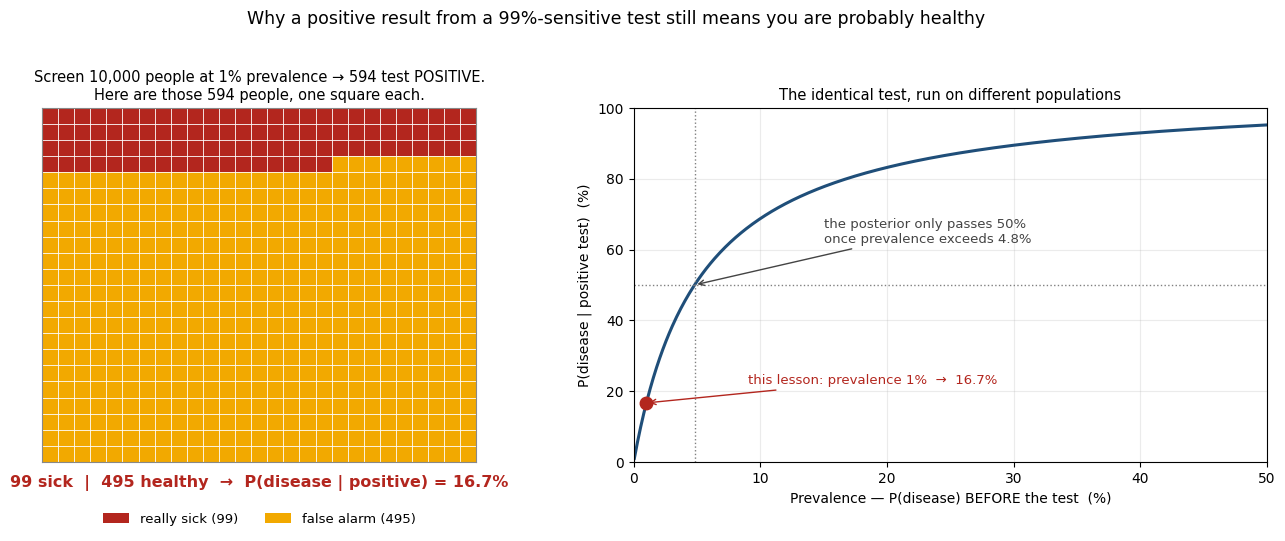

In [4]:
# SEE the base-rate result, do not just read it.
# WHAT: two views of the SAME medical test computed above - an icon array of every
#       person who tests positive, and the posterior as the prevalence changes.
# WHY:  the printed number "P(Disease|Positive) = 0.1667" is easy to nod at and forget.
#       Drawn as 594 squares, the answer is impossible to misread: count the red block.
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.colors import ListedColormap
from matplotlib.patches import Patch

# Same three numbers the cell above used - nothing new is invented here.
P_D, SENS, FPR = 0.01, 0.99, 0.05

# Natural frequencies: run the test on 10,000 people so every count is a whole person.
N = 10_000
n_sick = int(round(N * P_D))          # 100 people actually have the disease
n_well = N - n_sick                   # 9,900 do not
tp = int(round(n_sick * SENS))        # 99 sick people correctly flagged
fn = n_sick - tp                      # 1 sick person missed
fp = int(round(n_well * FPR))         # 495 healthy people falsely flagged
n_pos = tp + fp                       # everyone who sees a POSITIVE result
ppv = tp / n_pos                      # P(disease | positive) - the number that matters

print(f"Of {N:,} people screened: {n_sick} are sick, {n_well:,} are healthy.")
print(f"   {tp} sick people test positive (true positives)")
print(f"   {fp} healthy people test positive (FALSE alarms)")
print(f"   {fn} sick person tests negative (missed)")
print(f"   -> {n_pos} positive results in total, of which {tp} are real = {ppv:.1%}")

# --- Panel 1: one square per person who tested positive (22 x 27 = 594 exactly) ---
rows, cols = 22, 27
pos_grid = np.ones(rows * cols, dtype=int)   # 1 = healthy, false alarm
pos_grid[:tp] = 0                            # 0 = really sick (true positive)
pos_grid = pos_grid.reshape(rows, cols)
cmap = ListedColormap(["#b3261e", "#f2a900"])

fig, axes = plt.subplots(1, 2, figsize=(13.5, 5.4),
                         gridspec_kw={"width_ratios": [1.0, 1.15]})
ax = axes[0]
ax.imshow(pos_grid, cmap=cmap, vmin=0, vmax=1, interpolation="nearest")
ax.set_xticks([]); ax.set_yticks([])
ax.set_xticks(np.arange(-.5, cols, 1), minor=True)   # thin white lines = one square per person
ax.set_yticks(np.arange(-.5, rows, 1), minor=True)
ax.grid(which="minor", color="white", linewidth=0.6)
ax.tick_params(which="minor", length=0)
for sp in ax.spines.values():
    sp.set_edgecolor("#888")
ax.set_title(f"Screen 10,000 people at 1% prevalence → {n_pos} test POSITIVE.\n"
             f"Here are those {n_pos} people, one square each.", fontsize=10.5)
ax.text(0.5, -0.07,
        f"{tp} sick  |  {fp} healthy  →  P(disease | positive) = {ppv:.1%}",
        transform=ax.transAxes, ha="center", fontsize=11.5, weight="bold", color="#b3261e")
ax.legend(handles=[Patch(facecolor="#b3261e", label=f"really sick ({tp})"),
                   Patch(facecolor="#f2a900", label=f"false alarm ({fp})")],
          loc="upper center", bbox_to_anchor=(0.5, -0.11), ncol=2, fontsize=9.5, frameon=False)

# --- Panel 2: hold the test fixed, sweep the prevalence ---
# WHY: the test never changes here. Only the population does - and the answer moves from
#      almost-certainly-healthy to almost-certainly-sick. That is the base rate at work.
ax = axes[1]
p = np.linspace(0.0005, 0.5, 600)
post = SENS * p / (SENS * p + FPR * (1 - p))       # Bayes' theorem, vectorised over prevalence
ax.plot(p * 100, post * 100, color="#1f4e79", lw=2.2)
p_half = FPR / (SENS + FPR)                         # prevalence at which the posterior hits 50%
ax.axhline(50, color="grey", ls=":", lw=1)
ax.axvline(p_half * 100, color="grey", ls=":", lw=1)
ax.plot([P_D * 100], [ppv * 100], "o", color="#b3261e", ms=9, zorder=5)
ax.annotate(f"this lesson: prevalence 1%  →  {ppv:.1%}",
            xy=(P_D * 100, ppv * 100), xytext=(9, 22), fontsize=9.5, color="#b3261e",
            arrowprops=dict(arrowstyle="->", color="#b3261e"))
ax.annotate(f"the posterior only passes 50%\nonce prevalence exceeds {p_half*100:.1f}%",
            xy=(p_half * 100, 50), xytext=(15, 62), fontsize=9.5, color="#444",
            arrowprops=dict(arrowstyle="->", color="#444"))
ax.set_xlabel("Prevalence — P(disease) BEFORE the test  (%)")
ax.set_ylabel("P(disease | positive test)  (%)")
ax.set_title("The identical test, run on different populations", fontsize=10.5)
ax.set_xlim(0, 50); ax.set_ylim(0, 100); ax.grid(alpha=.25)

fig.suptitle("Why a positive result from a 99%-sensitive test still means you are probably healthy",
             fontsize=12.5, y=0.995)
fig.tight_layout(rect=[0, 0.05, 1, 0.94])
plt.show()


### 📊 Read the figure

**Left — count the red.** Every square is one of the **594 people who got a positive result**. Only the top **99** are actually sick; the remaining **495** are healthy people who got a false alarm. The red block is roughly one-sixth of the square, and that fraction *is* the answer: **P(disease | positive) = 16.7%**, the same 0.1667 the cell above printed. The test is 99% sensitive and it is still wrong five times out of six — because 5% of a very large healthy group outnumbers 99% of a very small sick group.

**Right — nothing about the test changes along this curve.** Sensitivity stays at 99% and the false-positive rate stays at 5%; only the *population* moves. At 1% prevalence (the red dot) a positive means 16.7%. The posterior does not even reach 50% until prevalence passes **4.8%**. This is the practical rule the curve proves: **the same test means different things in a screening programme and in a specialist clinic**, and reporting one number without the base rate is reporting nothing.

---


## Part 4: Probability Distributions

**The Story**: We learned basic probability, but real-world data follows patterns called "distributions"!

**BEFORE**: We know how to calculate probability, but don't understand common patterns in data.
**AFTER**: We learn about probability distributions — and, just as importantly, we learn how
far a **real** distribution departs from the tidy bell curve in the textbook.

We use the real recorded ages of the 1912 Titanic passengers.

✅ AFTER: Probability Distributions (Common Patterns in Data)

📊 Example 1: Normal Distribution (Bell Curve)
   Real data: recorded ages of Titanic passengers (1912 manifest)
   Pattern: most values cluster around the mean, fewer at the extremes

   Passengers on the manifest: 891
   Ages actually recorded: 714  (177 passengers have NO recorded age — a real gap, not noise)

   Real ages: mean = 29.7 years, std = 14.5 years
   Most passengers: 15 to 44 years
   Unusually old (> 59 years): 28 passengers
   Unusually young (< 0.67 years): 1 passenger(s)
      ^ note how low that threshold falls: age cannot go below 0, so the
        'two standard deviations below the mean' rule runs off the bottom of
        the real range. A bounded quantity is never truly normal.
   Youngest on board: 0.42 years | Oldest: 80 years
   Skewness: +0.39 (0 would be a perfectly symmetric bell curve)



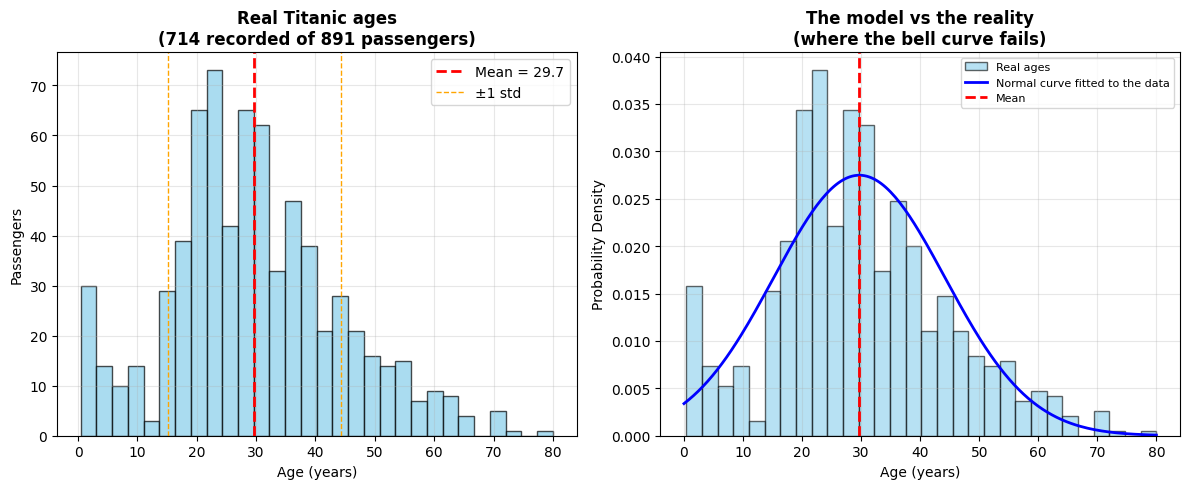

📊 How normal is it, really?
   Real ages within ±1 std of the mean : 72.3%
   A perfect normal distribution gives : 68.3%
   Children under 10 on board          : 62 (8.7%) — the bump on the left of the histogram

🔗 HOW THIS HELPS IN REAL LIFE:
   • Medical: 'Is this patient's measurement normal?' (compare to a distribution)
   • Quality Control: 'Is this product within normal range?'
   • Sports: 'Is this athlete's performance exceptional?'

⚠️  And the honest lesson only real data can teach: the bell curve is a MODEL,
   not the truth. The real age distribution has a bump of young children on the
   left that no normal curve can reproduce, and 177 passengers whose age was
   never written down at all. Invented 'heights' from np.random.normal would
   have fitted perfectly — and taught you nothing about either problem.


In [5]:
# Probability Distributions: Common Patterns in Real Data
# BEFORE: Don't understand patterns in data
# AFTER: Learn about Normal, Binomial distributions - patterns everywhere!

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

print("=" * 70)
print("✅ AFTER: Probability Distributions (Common Patterns in Data)")
print("=" * 70)
print()

# Normal Distribution (Bell Curve) — measured on REAL data, not invented
# We use the ages actually recorded for Titanic passengers in 1912.
print("📊 Example 1: Normal Distribution (Bell Curve)")
print("   Real data: recorded ages of Titanic passengers (1912 manifest)")
print("   Pattern: most values cluster around the mean, fewer at the extremes")
print()

titanic_ages = pd.read_csv("../../../Course 04/datasets/raw/titanic.csv")

# Real data has real gaps: 177 of the 891 passengers have no recorded age.
n_total = len(titanic_ages)
ages = titanic_ages["Age"].dropna().to_numpy()
print(f"   Passengers on the manifest: {n_total}")
print(f"   Ages actually recorded: {len(ages)}  "
      f"({n_total - len(ages)} passengers have NO recorded age — a real gap, not noise)")
print()

# We ESTIMATE the parameters from the data instead of choosing them.
mean = float(np.mean(ages))
std = float(np.std(ages))

print(f"   Real ages: mean = {mean:.1f} years, std = {std:.1f} years")
print(f"   Most passengers: {mean-std:.0f} to {mean+std:.0f} years")
print(f"   Unusually old (> {mean+2*std:.0f} years): {int(np.sum(ages > mean+2*std))} passengers")
n_low = int(np.sum(ages < mean - 2 * std))
print(f"   Unusually young (< {mean-2*std:.2f} years): {n_low} passenger(s)")
print(f"      ^ note how low that threshold falls: age cannot go below 0, so the")
print(f"        'two standard deviations below the mean' rule runs off the bottom of")
print(f"        the real range. A bounded quantity is never truly normal.")
print(f"   Youngest on board: {ages.min():.2f} years | Oldest: {ages.max():.0f} years")
print(f"   Skewness: {float(pd.Series(ages).skew()):+.2f} "
      f"(0 would be a perfectly symmetric bell curve)")
print()

# Visualize Normal Distribution
plt.figure(figsize=(12, 5))

# Subplot 1: Histogram of the REAL ages
plt.subplot(1, 2, 1)
plt.hist(ages, bins=30, color='skyblue', alpha=0.7, edgecolor='black')
plt.axvline(mean, color='red', linestyle='--', linewidth=2, label=f'Mean = {mean:.1f}')
plt.axvline(mean+std, color='orange', linestyle='--', linewidth=1, label='±1 std')
plt.axvline(mean-std, color='orange', linestyle='--', linewidth=1)
plt.xlabel('Age (years)')
plt.ylabel('Passengers')
plt.title('Real Titanic ages\n(714 recorded of 891 passengers)', fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)

# Subplot 2: the fitted bell curve laid OVER the real data, so the mismatch is visible
plt.subplot(1, 2, 2)
plt.hist(ages, bins=30, density=True, color='skyblue', alpha=0.6,
         edgecolor='black', label='Real ages')
x = np.linspace(0, ages.max(), 200)
pdf = stats.norm.pdf(x, mean, std)  # Normal fitted to the real mean and std
plt.plot(x, pdf, 'b-', linewidth=2, label='Normal curve fitted to the data')
plt.axvline(mean, color='red', linestyle='--', linewidth=2, label='Mean')
plt.xlabel('Age (years)')
plt.ylabel('Probability Density')
plt.title('The model vs the reality\n(where the bell curve fails)', fontweight='bold')
plt.legend(fontsize=8)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Quantify the mismatch instead of eyeballing it: what fraction of real ages fall
# within one standard deviation? A true normal distribution would give 68.3%.
within_1sd = float(np.mean(np.abs(ages - mean) <= std))
print(f"📊 How normal is it, really?")
print(f"   Real ages within ±1 std of the mean : {within_1sd:.1%}")
print(f"   A perfect normal distribution gives : 68.3%")
print(f"   Children under 10 on board          : {int(np.sum(ages < 10))} "
      f"({np.mean(ages < 10):.1%}) — the bump on the left of the histogram")
print()
print("🔗 HOW THIS HELPS IN REAL LIFE:")
print("   • Medical: 'Is this patient's measurement normal?' (compare to a distribution)")
print("   • Quality Control: 'Is this product within normal range?'")
print("   • Sports: 'Is this athlete's performance exceptional?'")
print()
print("⚠️  And the honest lesson only real data can teach: the bell curve is a MODEL,")
print("   not the truth. The real age distribution has a bump of young children on the")
print("   left that no normal curve can reproduce, and 177 passengers whose age was")
print("   never written down at all. Invented 'heights' from np.random.normal would")
print("   have fitted perfectly — and taught you nothing about either problem.")


## Part 5: Monte Carlo Simulation

**The Story**: Some problems are too complex to solve exactly - but we can simulate them!

**BEFORE**: We can't solve complex probability problems exactly.
**AFTER**: Monte Carlo simulation uses random sampling to approximate solutions - works for any problem!

AFTER: Monte Carlo Simulation

REAL-LIFE EXAMPLE: Estimating pi using Monte Carlo
   Problem: pi = 3.14159... (infinite decimals)
   Solution: Use random simulation to approximate!

   Estimated pi: 3.155600
   Actual pi:    3.141593
   Error:        0.014007

   How the estimate improves as samples are added:
     samples   estimate     error    error x sqrt(n)
          10     2.8000    0.3416               1.08
         100     3.0800    0.0616               0.62
       1,000     3.1960    0.0544               1.72
      10,000     3.1556    0.0140               1.40
   ^ the last column stays roughly flat: the error falls like 1/sqrt(n),
     so 100x more samples buys only 10x more accuracy.



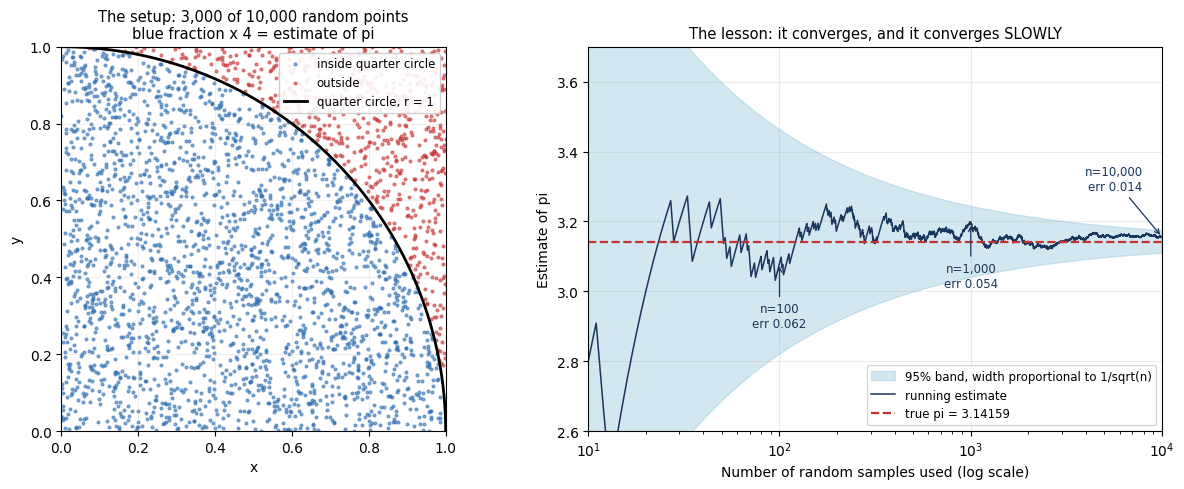

HOW THIS HELPS IN REAL LIFE:
   - Finance: Estimate portfolio risk (simulate market scenarios)
   - Engineering: Estimate failure probability (simulate stresses)
   - Science: Estimate complex integrals (too hard to solve exactly)
   - Any complex problem: Simulate and approximate!


In [6]:
# Monte Carlo Simulation: Solving Complex Problems by Simulation
# BEFORE: Can't solve complex probability problems exactly
# AFTER: Use random simulation to approximate - works for ANY problem!
#
# NOTE ON RANDOMNESS: every other dataset in this lesson is real recorded data.
# Here the randomness IS the subject - Monte Carlo is a method built out of random
# sampling - so np.random is the thing being taught, not a stand-in for missing data.

import numpy as np
import matplotlib.pyplot as plt

def monte_carlo_pi(n_samples=10000):
    """
    Monte Carlo method to estimate pi.

    THE PROBLEM: Finding pi exactly is hard (infinite decimals).
    THE SOLUTION: Use random simulation to approximate!

    How it works:
    1. Randomly throw points in a square
    2. Count points inside circle
    3. Use ratio to estimate pi

    This is REAL-LIFE application: Approximate complex problems!
    """
    np.random.seed(42)  # fixed seed so the figure below is the same in every classroom

    # Generate random points in unit square [0,1] x [0,1]
    x = np.random.uniform(0, 1, n_samples)  # Random x coordinates
    y = np.random.uniform(0, 1, n_samples)  # Random y coordinates

    # Check if point is inside unit circle (distance from origin < 1)
    # Circle equation: x^2 + y^2 = 1
    distances = np.sqrt(x**2 + y**2)  # Distance from origin
    inside_circle = distances < 1     # Points inside circle

    # Estimate pi using the ratio.
    # Area of quarter circle = pi/4 ; area of unit square = 1 ; so pi ~ 4 x ratio
    pi_estimate = 4 * (np.sum(inside_circle) / n_samples)

    return pi_estimate, x, y, inside_circle

print("=" * 70)
print("AFTER: Monte Carlo Simulation")
print("=" * 70)
print()

# Example: Estimating pi using Monte Carlo
print("REAL-LIFE EXAMPLE: Estimating pi using Monte Carlo")
print("   Problem: pi = 3.14159... (infinite decimals)")
print("   Solution: Use random simulation to approximate!")
print()

N = 10_000
pi_est, x, y, inside = monte_carlo_pi(N)

print(f"   Estimated pi: {pi_est:.6f}")
print(f"   Actual pi:    {np.pi:.6f}")
print(f"   Error:        {abs(pi_est - np.pi):.6f}")
print()

# ---- The running estimate: what the method does as samples arrive -----------
# WHAT: after each new point, recompute the estimate from ALL points so far.
# WHY:  a single final number hides the whole story. The interesting fact about
#       Monte Carlo is not that it works, but HOW SLOWLY it improves.
n_axis = np.arange(1, N + 1)
running = 4.0 * np.cumsum(inside) / n_axis          # estimate after n points
p = np.pi / 4.0                                     # true probability of landing inside
se = 4.0 * np.sqrt(p * (1 - p) / n_axis)            # standard error, shrinks like 1/sqrt(n)

# A printed step table to go with the picture - the same numbers, readable exactly.
print("   How the estimate improves as samples are added:")
print(f"   {'samples':>9} {'estimate':>10} {'error':>9}   {'error x sqrt(n)':>16}")
for n in (10, 100, 1_000, 10_000):
    est = running[n - 1]
    err = abs(est - np.pi)
    print(f"   {n:>9,} {est:>10.4f} {err:>9.4f}   {err * np.sqrt(n):>16.2f}")
print("   ^ the last column stays roughly flat: the error falls like 1/sqrt(n),")
print("     so 100x more samples buys only 10x more accuracy.")
print()

# ---- Two panels: the setup, and the convergence ------------------------------
fig, axes = plt.subplots(1, 2, figsize=(12.6, 5.0))

ax = axes[0]
show = 3000  # draw a subsample so individual points stay visible on a projector
ax.scatter(x[:show][inside[:show]], y[:show][inside[:show]],
           s=4, c="#2b6cb0", alpha=0.55, label=f"inside quarter circle")
ax.scatter(x[:show][~inside[:show]], y[:show][~inside[:show]],
           s=4, c="#c53030", alpha=0.55, label="outside")
theta = np.linspace(0, np.pi / 2, 200)
ax.plot(np.cos(theta), np.sin(theta), color="black", lw=2, label="quarter circle, r = 1")
ax.set_xlim(0, 1); ax.set_ylim(0, 1); ax.set_aspect("equal")
ax.set_xlabel("x"); ax.set_ylabel("y")
ax.set_title(f"The setup: {show:,} of {N:,} random points\n"
             f"blue fraction x 4 = estimate of pi", fontsize=10.5)
ax.legend(loc="upper right", fontsize=8.5, framealpha=0.9)
ax.grid(alpha=0.2)

ax = axes[1]
ax.fill_between(n_axis, np.pi - 1.96 * se, np.pi + 1.96 * se,
                color="#9ecae1", alpha=0.45,
                label="95% band, width proportional to 1/sqrt(n)")
ax.plot(n_axis, running, color="#1a365d", lw=1.1, label="running estimate")
ax.axhline(np.pi, color="#c53030", ls="--", lw=1.6, label=f"true pi = {np.pi:.5f}")
ax.set_xscale("log")
ax.set_xlim(10, N)
ax.set_ylim(2.6, 3.7)
ax.set_xlabel("Number of random samples used (log scale)")
ax.set_ylabel("Estimate of pi")
ax.set_title("The lesson: it converges, and it converges SLOWLY", fontsize=10.5)
ax.legend(loc="lower right", fontsize=8.5)
ax.grid(alpha=0.25)
# Keep each label off the plot edge so nothing is clipped on a projector.
for n, dx, dy, ha in [(100, 0, -46, "center"), (1_000, 0, -46, "center"),
                      (10_000, -14, 34, "right")]:
    ax.annotate(f"n={n:,}\nerr {abs(running[n-1]-np.pi):.3f}",
                xy=(n, running[n - 1]), xytext=(dx, dy),
                textcoords="offset points", ha=ha, fontsize=8.5, color="#1a365d",
                arrowprops=dict(arrowstyle="->", color="#1a365d", lw=0.9))

fig.tight_layout()
plt.show()

print("HOW THIS HELPS IN REAL LIFE:")
print("   - Finance: Estimate portfolio risk (simulate market scenarios)")
print("   - Engineering: Estimate failure probability (simulate stresses)")
print("   - Science: Estimate complex integrals (too hard to solve exactly)")
print("   - Any complex problem: Simulate and approximate!")


### 📊 Read the figure

**Left — the setup.** 3,000 of the 10,000 random points are drawn (all 10,000 would fill the square solid). Blue points landed inside the quarter circle, red outside. The quarter circle has area π/4 and the square has area 1, so the blue *fraction* times 4 estimates π. Nothing here is a formula for π; it is a count.

**Right — the actual lesson.** The dark line is the estimate recomputed after every new point, on a log x-axis. It starts wild, then settles onto the red dashed line at π. The blue band is the 95% interval, and its width shrinks like **1/√n** — so it narrows fast at first and then almost stops. Read the annotations left to right: 100 samples, 1,000 samples, 10,000 samples. The printed table above says the same thing in the last column, which stays roughly flat: **error × √n is a constant**.

**What this proves:** Monte Carlo always works and is never cheap. Buying one more decimal digit of accuracy costs **100× more samples**. That trade-off is why Monte Carlo is the method of choice for problems with no formula, and the method of last resort for problems that have one.

---


## Part 6: Real-World Application: Medical Diagnosis System

**The Story**: Let's build a complete medical diagnosis system using everything we learned!

**BEFORE**: Doctors make decisions based on experience alone.
**AFTER**: We build a system that combines probabilities, Bayes' theorem, and decision-making to help doctors!

In [7]:
# Real-World Application: Medical Diagnosis System
# BEFORE: Doctors make decisions based on experience alone
# AFTER: System that combines probability, Bayes' theorem, and decision-making!

class MedicalDiagnosisSystem:
    """
    Medical Diagnosis System: Real-world application of uncertainty.
    
    THE PROBLEM: Doctors need to make decisions with incomplete information.
    THE SOLUTION: Use probability and Bayesian inference to help!
    
    This is how AI helps in REAL LIFE:
    - Medical diagnosis
    - Treatment recommendations
    - Risk assessment
    """
    def __init__(self):
        """Initialize medical diagnosis system"""
        self.diseases = {}  # Dictionary: disease -> probability
        self.symptoms = {}  # Dictionary: symptom -> probabilities for each disease
        print("✅ Created Medical Diagnosis System")
    
    def add_disease(self, disease, prevalence):
        """
        Add a disease with its prevalence (how common it is).
        
        Prevalence = probability of having this disease in general population.
        Example: P(Flu) = 0.1 means 10% of people have flu
        """
        self.diseases[disease] = prevalence  # Store disease prevalence
        if disease not in self.symptoms:
            self.symptoms[disease] = {}  # Create symptom dictionary for this disease
        print(f"  ➕ Added disease: {disease} (prevalence: {prevalence:.2%})")
    
    def add_symptom_probability(self, disease, symptom, probability):
        """
        Add probability of symptom given disease.
        
        P(Symptom|Disease) = probability of having symptom if you have disease.
        Example: P(Fever|Flu) = 0.9 means 90% of flu patients have fever
        """
        if disease in self.symptoms:
            self.symptoms[disease][symptom] = probability  # Store symptom probability
            print(f"  ➕ P({symptom}|{disease}) = {probability:.2%}")
    
    def diagnose(self, patient_symptoms):
        """
        Diagnose patient based on symptoms using Bayesian inference.
        
        THE SOLUTION: Use Bayes' theorem to calculate P(Disease|Symptoms)
        This tells us: Given these symptoms, what's the probability of each disease?
        """
        print(f"\n🔍 Diagnosing patient with symptoms: {patient_symptoms}")
        print()
        
        diagnoses = {}
        
        # Calculate probability for each disease using Bayes' theorem
        for disease, prevalence in self.diseases.items():
            # Prior: P(Disease)
            prior = prevalence
            
            # Likelihood: P(Symptoms|Disease)
            # If patient has symptom and disease causes it, use that probability
            # If patient doesn't have symptom, use (1 - probability)
            likelihood = 1.0  # Start with 1 (multiplicative)
            
            for symptom, has_symptom in patient_symptoms.items():
                if disease in self.symptoms and symptom in self.symptoms[disease]:
                    p_symptom_given_disease = self.symptoms[disease][symptom]
                    if has_symptom:
                        likelihood *= p_symptom_given_disease  # Patient has symptom
                    else:
                        likelihood *= (1 - p_symptom_given_disease)  # Patient doesn't have symptom
            
            # Evidence: P(Symptoms) - normalize across all diseases
            # (For simplicity, we'll use unnormalized probabilities)
            
            # Posterior: P(Disease|Symptoms) ≈ P(Symptoms|Disease) × P(Disease)
            posterior = likelihood * prior
            diagnoses[disease] = posterior
        
        # Normalize probabilities (sum to 1)
        total = sum(diagnoses.values())
        if total > 0:
            for disease in diagnoses:
                diagnoses[disease] /= total
        
        return diagnoses

# Example: Building a medical diagnosis system
print("=" * 70)
print("✅ AFTER: Real-World Application - Medical Diagnosis System")
print("=" * 70)
print()

system = MedicalDiagnosisSystem()

print("\n➕ Adding diseases and probabilities:")
# Add diseases with their prevalence
system.add_disease("Common Cold", 0.15)  # 15% of people have cold
system.add_disease("Flu", 0.05)          # 5% of people have flu
system.add_disease("COVID-19", 0.02)     # 2% of people have COVID

print("\n➕ Adding symptom probabilities:")
# Flu symptoms
system.add_symptom_probability("Flu", "Fever", 0.9)      # 90% of flu patients have fever
system.add_symptom_probability("Flu", "Cough", 0.8)      # 80% have cough
system.add_symptom_probability("Flu", "Fatigue", 0.7)    # 70% have fatigue

# COVID-19 symptoms
system.add_symptom_probability("COVID-19", "Fever", 0.85)
system.add_symptom_probability("COVID-19", "Cough", 0.9)
system.add_symptom_probability("COVID-19", "Fatigue", 0.6)

# Common Cold symptoms
system.add_symptom_probability("Common Cold", "Fever", 0.2)   # Less likely
system.add_symptom_probability("Common Cold", "Cough", 0.7)
system.add_symptom_probability("Common Cold", "Fatigue", 0.4)

print("\n📊 Diagnosing patient:")
# Patient has: Fever, Cough, Fatigue
patient_symptoms = {
    "Fever": True,
    "Cough": True,
    "Fatigue": True
}

diagnoses = system.diagnose(patient_symptoms)

print("\n📊 Diagnosis Results (Probability of each disease):")
sorted_diagnoses = sorted(diagnoses.items(), key=lambda x: x[1], reverse=True)
for disease, probability in sorted_diagnoses:
    print(f"   {disease}: {probability:.2%}")

most_likely = sorted_diagnoses[0][0]
print(f"\n✅ Most likely diagnosis: {most_likely} ({diagnoses[most_likely]:.2%})")

print("\n🔗 HOW THIS HELPS IN REAL LIFE:")
print("   • Doctors: Use as decision support tool")
print("   • Triage: Prioritize patients based on probability")
print("   • Treatment: Choose treatment based on most likely disease")
print("   • Resource allocation: Allocate resources based on risk")


✅ AFTER: Real-World Application - Medical Diagnosis System

✅ Created Medical Diagnosis System

➕ Adding diseases and probabilities:
  ➕ Added disease: Common Cold (prevalence: 15.00%)
  ➕ Added disease: Flu (prevalence: 5.00%)
  ➕ Added disease: COVID-19 (prevalence: 2.00%)

➕ Adding symptom probabilities:
  ➕ P(Fever|Flu) = 90.00%
  ➕ P(Cough|Flu) = 80.00%
  ➕ P(Fatigue|Flu) = 70.00%
  ➕ P(Fever|COVID-19) = 85.00%
  ➕ P(Cough|COVID-19) = 90.00%
  ➕ P(Fatigue|COVID-19) = 60.00%
  ➕ P(Fever|Common Cold) = 20.00%
  ➕ P(Cough|Common Cold) = 70.00%
  ➕ P(Fatigue|Common Cold) = 40.00%

📊 Diagnosing patient:

🔍 Diagnosing patient with symptoms: {'Fever': True, 'Cough': True, 'Fatigue': True}


📊 Diagnosis Results (Probability of each disease):
   Flu: 58.91%
   COVID-19: 21.46%
   Common Cold: 19.64%

✅ Most likely diagnosis: Flu (58.91%)

🔗 HOW THIS HELPS IN REAL LIFE:
   • Doctors: Use as decision support tool
   • Triage: Prioritize patients based on probability
   • Treatment: Choose tr

## Part 7: Expected Utility & Decision Making

**The Story**: We learned about probability, but how do we use it to make decisions?

**BEFORE**: We make decisions based on gut feeling or guesswork.
**AFTER**: We use expected utility to make optimal decisions under uncertainty!

In [8]:
# Decision-making under uncertainty: pick the option with the highest EXPECTED utility.
# Why: probabilities alone do not make choices - expected utility turns them into a decision rule.

class DecisionMaker:
    """
    Decision Maker: Make optimal decisions under uncertainty.
    
    THE PROBLEM: We need to make decisions with uncertain outcomes.
    THE SOLUTION: Use expected utility = sum(probability × outcome) for each option
    
    How it works:
    1. List all possible outcomes for each decision
    2. Assign probabilities to each outcome
    3. Calculate expected utility for each decision
    4. Choose decision with highest expected utility
    """
    def __init__(self):
        """Initialize decision maker"""
        self.decisions = {}  # Dictionary: decision -> outcomes
        print("✅ Created Decision Maker")
    
    def add_decision(self, decision_name, outcomes):
        """
        Add a decision with its possible outcomes.
        
        Parameters:
        - decision_name: Name of decision (e.g., "Invest in Stock A")
        - outcomes: List of (probability, utility) tuples
          Example: [(0.3, 100), (0.7, -50)] means:
            30% chance of +100 utility, 70% chance of -50 utility
        """
        self.decisions[decision_name] = outcomes
        print(f"  ➕ Added decision: {decision_name}")
        for prob, util in outcomes:
            print(f"      • {prob:.0%} chance of {util:+.0f} utility")
    
    def calculate_expected_utility(self, decision_name):
        """
        Calculate expected utility for a decision.
        
        Formula: E[Utility] = Σ (Probability × Utility)
        This tells us: On average, what's the expected outcome?
        """
        if decision_name not in self.decisions:
            return None
        
        outcomes = self.decisions[decision_name]
        expected_util = sum(prob * util for prob, util in outcomes)
        
        return expected_util
    
    def make_optimal_decision(self):
        """
        Find the optimal decision (highest expected utility).
        
        THE SOLUTION: Choose decision that maximizes expected utility!
        This is how we make optimal decisions under uncertainty.
        """
        print("\n📊 Calculating expected utility for each decision:")
        print()
        
        expected_utils = {}
        for decision, outcomes in self.decisions.items():
            expected_util = self.calculate_expected_utility(decision)
            expected_utils[decision] = expected_util
            print(f"   {decision}:")
            print(f"      Expected Utility = {expected_util:.2f}")
            for prob, util in outcomes:
                print(f"         {prob:.0%} × {util:+.0f} = {prob*util:+.2f}")
            print()
        
        # Find optimal decision
        optimal_decision = max(expected_utils.items(), key=lambda x: x[1])
        
        print("=" * 70)
        print(f"✅ OPTIMAL DECISION: {optimal_decision[0]}")
        print(f"   Expected Utility: {optimal_decision[1]:+.2f}")
        print("=" * 70)
        
        return optimal_decision[0], optimal_decision[1]

# Example: Investment Decision
print("=" * 70)
print("✅ AFTER: Expected Utility & Decision Making")
print("=" * 70)
print()

dm = DecisionMaker()

print("\n📊 REAL-LIFE EXAMPLE: Investment Decision")
print("   Problem: Should I invest in Stock A or Stock B?")
print("   Solution: Calculate expected utility for each option!")
print()

print("\n➕ Adding investment options:")
# Option 1: Stock A
# 60% chance of +$500 profit, 40% chance of -$200 loss
dm.add_decision("Invest in Stock A", [(0.6, 500), (0.4, -200)])

# Option 2: Stock B
# 30% chance of +$1000 profit, 70% chance of -$100 loss
dm.add_decision("Invest in Stock B", [(0.3, 1000), (0.7, -100)])

# Option 3: Don't invest (safe option)
# 100% chance of $0 (no risk, no gain)
dm.add_decision("Don't Invest (Safe)", [(1.0, 0)])

# Make optimal decision
optimal, utility = dm.make_optimal_decision()

print("\n🔗 HOW THIS HELPS IN REAL LIFE:")
print("   • Business: Choose best investment or strategy")
print("   • Medicine: Choose best treatment option")
print("   • Engineering: Choose best design option")
print("   • Any decision with uncertain outcomes!")
print()
print("📊 BEFORE vs AFTER:")
print("   BEFORE: 'I think Stock B is better' (gut feeling)")
print("   AFTER: 'Stock B has highest expected utility' (optimal decision!)")

✅ AFTER: Expected Utility & Decision Making

✅ Created Decision Maker

📊 REAL-LIFE EXAMPLE: Investment Decision
   Problem: Should I invest in Stock A or Stock B?
   Solution: Calculate expected utility for each option!


➕ Adding investment options:
  ➕ Added decision: Invest in Stock A
      • 60% chance of +500 utility
      • 40% chance of -200 utility
  ➕ Added decision: Invest in Stock B
      • 30% chance of +1000 utility
      • 70% chance of -100 utility
  ➕ Added decision: Don't Invest (Safe)
      • 100% chance of +0 utility

📊 Calculating expected utility for each decision:

   Invest in Stock A:
      Expected Utility = 220.00
         60% × +500 = +300.00
         40% × -200 = -80.00

   Invest in Stock B:
      Expected Utility = 230.00
         30% × +1000 = +300.00
         70% × -100 = -70.00

   Don't Invest (Safe):
      Expected Utility = 0.00
         100% × +0 = +0.00

✅ OPTIMAL DECISION: Invest in Stock B
   Expected Utility: +230.00

🔗 HOW THIS HELPS IN REAL LI

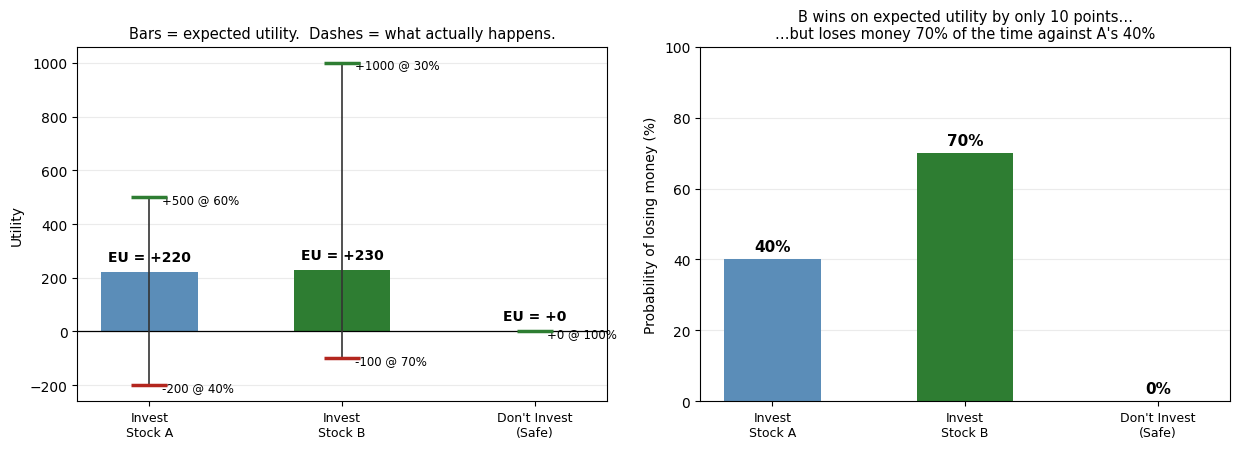

Expected utility  A = +220   B = +230   Safe = +0   -> the rule picks B, by 10 points out of 230.
Probability of a LOSS   A = 40%   B = 70%   Safe = 0%


In [9]:
# SEE what "maximise expected utility" hides.
# WHAT: bars are the expected utilities computed above; the dashes on top of each bar are the
#       outcomes that actually occur, with their probabilities. The right panel is the chance
#       of losing money.
# WHY:  the decision rule picked Stock B. Expected utility is a single number, and a single
#       number cannot show you that B's win is tiny and B's downside is far more likely.
import numpy as np
import matplotlib.pyplot as plt

# The exact options fed to the DecisionMaker above: (probability, utility) pairs.
opts = [("Invest in Stock A",   [(0.60, 500), (0.40, -200)]),
        ("Invest in Stock B",   [(0.30, 1000), (0.70, -100)]),
        ("Don't Invest (Safe)", [(1.00, 0)])]
names = [o[0] for o in opts]
eu = [sum(p * u for p, u in outs) for _, outs in opts]              # E[U] = sum(p x u)
ploss = [sum(p for p, u in outs if u < 0) for _, outs in opts]      # P(outcome is a loss)

fig, axes = plt.subplots(1, 2, figsize=(12.5, 4.6))
x = np.arange(len(opts))
colours = ["#5b8db8", "#2e7d32", "#9e9e9e"]
labels = [n.replace(" in ", "\n").replace(" (Safe)", "\n(Safe)") for n in names]

ax = axes[0]
ax.bar(x, eu, color=colours, width=0.5, zorder=2)
for i, (_, outs) in enumerate(opts):
    vals = [u for _, u in outs]
    ax.plot([i, i], [min(vals), max(vals)], color="#333", lw=1.2, zorder=3)   # the real spread
    for p, u in outs:
        ax.plot(i, u, "_", ms=26, color="#b3261e" if u < 0 else "#2e7d32", mew=2.5, zorder=4)
        ax.annotate(f"{u:+.0f} @ {p:.0%}", (i, u), xytext=(9, -4),
                    textcoords="offset points", fontsize=8.5)
for i, v in enumerate(eu):
    ax.annotate(f"EU = {v:+.0f}", (i, v), xytext=(0, 8 if v >= 0 else -16),
                textcoords="offset points", ha="center", fontsize=10, weight="bold")
ax.axhline(0, color="black", lw=0.9)
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Utility")
ax.set_title("Bars = expected utility.  Dashes = what actually happens.", fontsize=10.5)
ax.grid(axis="y", alpha=.25, zorder=0)

ax = axes[1]
ax.bar(x, [p * 100 for p in ploss], color=colours, width=0.5, zorder=2)
for i, p in enumerate(ploss):
    ax.annotate(f"{p:.0%}", (i, p * 100), xytext=(0, 6), textcoords="offset points",
                ha="center", fontsize=11, weight="bold")
ax.set_xticks(x); ax.set_xticklabels(labels, fontsize=9)
ax.set_ylabel("Probability of losing money (%)")
ax.set_ylim(0, 100)
ax.set_title(f"B wins on expected utility by only {eu[1]-eu[0]:.0f} points…\n"
             f"…but loses money {ploss[1]:.0%} of the time against A's {ploss[0]:.0%}",
             fontsize=10.5)
ax.grid(axis="y", alpha=.25, zorder=0)
fig.tight_layout()
plt.show()

print(f"Expected utility  A = {eu[0]:+.0f}   B = {eu[1]:+.0f}   Safe = {eu[2]:+.0f}"
      f"   -> the rule picks B, by {eu[1]-eu[0]:.0f} points out of {eu[1]:.0f}.")
print(f"Probability of a LOSS   A = {ploss[0]:.0%}   B = {ploss[1]:.0%}   Safe = {ploss[2]:.0%}")


### 📊 Read the figure

**Left panel.** The three bars are the expected utilities the code just computed: **A = +220, B = +230, Safe = 0**. The dashes above and below each bar are the outcomes that can actually happen. Notice that **no bar is ever an outcome** — nobody ever receives +230 from Stock B; they receive +1000 or −100. Expected utility is an average over futures, not a thing that occurs.

**Right panel.** The rule says choose B. But B's margin over A is **10 points out of 230 — about 4%** — while B loses money **70%** of the time against A's **40%**. Two-thirds of B's expected utility comes from a single 30%-probability outcome.

**What this proves:** expected utility is the correct rule *if* you face the same decision many times and can absorb the losses. Run this decision once, with money you need, and the ranking is close enough to be an artefact of estimates that were themselves guesses. The number that decides is not the only number you should look at.

---


## Part 8: Practice: Real-World Risk Assessment

**The Story**: Let's apply everything we learned to assess real-world risks!

**BEFORE**: We make risky decisions without understanding probabilities.
**AFTER**: We use probability and decision-making to assess and manage risks properly!

In [10]:
# Real-World Application: Risk Assessment
# BEFORE: Make risky decisions without understanding probabilities
# AFTER: Use probability to assess and manage risks properly!

class RiskAssessor:
    """
    Risk Assessor: Assess and manage risks using probability.
    
    THE PROBLEM: We face risks but don't know how to evaluate them.
    THE SOLUTION: Use probability to quantify risk and make informed decisions!
    
    Risk = Probability × Impact
    This helps us understand: How likely is it? How bad would it be?
    """
    def __init__(self):
        """Initialize risk assessor"""
        self.risks = {}  # Dictionary: risk -> (probability, impact)
        print("✅ Created Risk Assessor")
    
    def add_risk(self, risk_name, probability, impact):
        """
        Add a risk with its probability and impact.
        
        Parameters:
        - risk_name: Name of risk (e.g., "Data breach")
        - probability: Probability of risk occurring (0 to 1)
        - impact: Impact if risk occurs (e.g., -100000 for $100k loss)
        """
        self.risks[risk_name] = (probability, impact)
        expected_loss = probability * impact
        print(f"  ➕ Risk: {risk_name}")
        print(f"      Probability: {probability:.1%}")
        print(f"      Impact: {impact:+,.0f}")
        print(f"      Expected Loss: {expected_loss:+,.0f}")
    
    def assess_all_risks(self):
        """
        Assess all risks and rank them by expected loss.
        
        Expected Loss = Probability × Impact
        This tells us: Which risks should we prioritize?
        """
        print("\n📊 Risk Assessment:")
        print()
        
        risk_scores = {}
        for risk_name, (prob, impact) in self.risks.items():
            expected_loss = prob * impact
            risk_scores[risk_name] = {
                'probability': prob, 'impact': impact,
                'expected_loss': expected_loss
            }
        
        # Sort by expected loss (worst/most negative first = highest priority)
        sorted_risks = sorted(risk_scores.items(), key=lambda x: x[1]['expected_loss'], reverse=False)  # reverse=False means ascending: -50,000 comes before -40,000 (most negative = worst risk first)
        
        print(f"{'Risk':<25} {'Probability':<15} {'Impact':<15} {'Expected Loss':<15}")
        print("-" * 70)
        
        for risk_name, info in sorted_risks:
            print(f"{risk_name:<25} {info['probability']:<15.1%} {info['impact']:<15,.0f} {info['expected_loss']:<15,.0f}")
        
        return sorted_risks
    
    def recommend_actions(self):
        """
        Recommend actions based on risk assessment.
        
        THE SOLUTION: Prioritize actions based on expected loss!
        High expected loss = high priority
        """
        sorted_risks = self.assess_all_risks()
        
        print("\n📋 Recommended Actions (Priority Order):")
        for i, (risk_name, info) in enumerate(sorted_risks[:3], 1):
            print(f"\n   {i}. {risk_name} (Expected Loss: {info['expected_loss']:,.0f})")
            if info['probability'] > 0.5:
                print(f"      → High probability! Take preventive measures.")
            if abs(info['impact']) > 50000:
                print(f"      → High impact! Prepare contingency plan.")
            print(f"      → Risk Score: {info['expected_loss']:,.0f}")

# Example: Business Risk Assessment
print("=" * 70)
print("✅ AFTER: Real-World Risk Assessment")
print("=" * 70)
print()

assessor = RiskAssessor()

print("\n📊 REAL-LIFE EXAMPLE: Business Risk Assessment")
print("   Problem: Which risks should we prioritize?")
print("   Solution: Use probability to calculate expected loss for each risk!")
print()

print("\n➕ Assessing business risks:")
# Add various business risks
assessor.add_risk("Data Breach", 0.05, -1000000)  # 5% chance, $1M loss
assessor.add_risk("Key Employee Leaves", 0.15, -50000)  # 15% chance, $50k loss
assessor.add_risk("Market Downturn", 0.20, -200000)  # 20% chance, $200k loss
assessor.add_risk("Supplier Failure", 0.10, -150000)  # 10% chance, $150k loss

# Get recommendations
assessor.recommend_actions()

print("\n🔗 HOW THIS HELPS IN REAL LIFE:")
print("   • Business: Prioritize risk management efforts")
print("   • Insurance: Calculate appropriate premiums")
print("   • Safety: Prioritize safety measures")
print("   • Finance: Manage portfolio risk")
print()
print("📊 BEFORE vs AFTER:")
print("   BEFORE: 'I think data breach is worst' (guess)")
print("   AFTER: 'Data Breach has highest expected loss (-50,000)' (data-driven!)")


✅ AFTER: Real-World Risk Assessment

✅ Created Risk Assessor

📊 REAL-LIFE EXAMPLE: Business Risk Assessment
   Problem: Which risks should we prioritize?
   Solution: Use probability to calculate expected loss for each risk!


➕ Assessing business risks:
  ➕ Risk: Data Breach
      Probability: 5.0%
      Impact: -1,000,000
      Expected Loss: -50,000
  ➕ Risk: Key Employee Leaves
      Probability: 15.0%
      Impact: -50,000
      Expected Loss: -7,500
  ➕ Risk: Market Downturn
      Probability: 20.0%
      Impact: -200,000
      Expected Loss: -40,000
  ➕ Risk: Supplier Failure
      Probability: 10.0%
      Impact: -150,000
      Expected Loss: -15,000

📊 Risk Assessment:

Risk                      Probability     Impact          Expected Loss  
----------------------------------------------------------------------
Data Breach               5.0%            -1,000,000      -50,000        
Market Downturn           20.0%           -200,000        -40,000        
Supplier Failure   

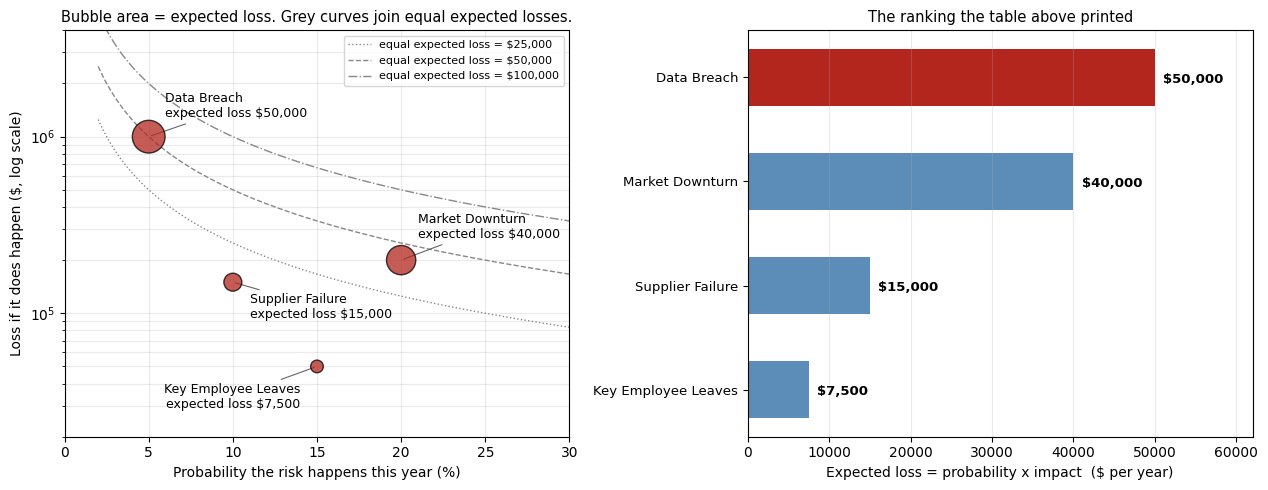

Data Breach ranks first at $50,000; Market Downturn is second at $40,000 - a gap of only $10,000.
Yet Data Breach is 4x rarer and 5x bigger than Market Downturn.
Expected loss ranks them side by side. They are not the same problem.


In [11]:
# SEE the risk table as a picture, not a ranking.
# WHAT: every risk placed by how LIKELY it is (x) against how BIG it is (y),
#       with dashed curves joining points of equal expected loss.
# WHY:  the table above sorts by one number, probability x impact. Two risks can
#       sit almost on top of each other in that ranking and still be completely
#       different problems to manage. The picture shows the difference; the column cannot.
import numpy as np
import matplotlib.pyplot as plt

# Exactly the four risks fed to the RiskAssessor above - illustrative business
# figures, stated as such, not measured data.
risks = [("Data Breach",          0.05, 1_000_000),
         ("Market Downturn",      0.20,   200_000),
         ("Supplier Failure",     0.10,   150_000),
         ("Key Employee Leaves",  0.15,    50_000)]
names   = [r[0] for r in risks]
probs   = np.array([r[1] for r in risks])
impacts = np.array([r[2] for r in risks], dtype=float)
exp_loss = probs * impacts                     # the number the table sorted on

fig, axes = plt.subplots(1, 2, figsize=(12.8, 5.0))

# --- Panel 1: the risk matrix -------------------------------------------------
ax = axes[0]
pg = np.linspace(0.02, 0.30, 200)
for level, style in [(25_000, ":"), (50_000, "--"), (100_000, "-.")]:
    ax.plot(pg * 100, level / pg, color="#888", lw=1.0, ls=style,
            label=f"equal expected loss = ${level:,.0f}")
ax.scatter(probs * 100, impacts, s=exp_loss / 90, c="#b3261e", alpha=0.75,
           edgecolor="black", zorder=5)
offsets = [(12, 14), (12, 16), (12, -26), (-12, -30)]
for (nm, pr, im, el, off) in zip(names, probs, impacts, exp_loss, offsets):
    ax.annotate(f"{nm}\nexpected loss ${el:,.0f}", xy=(pr * 100, im),
                xytext=off, textcoords="offset points", fontsize=9,
                ha="right" if off[0] < 0 else "left",
                arrowprops=dict(arrowstyle="-", color="#666", lw=0.8))
ax.set_yscale("log")
ax.set_xlim(0, 30); ax.set_ylim(2e4, 4e6)
ax.set_xlabel("Probability the risk happens this year (%)")
ax.set_ylabel("Loss if it does happen ($, log scale)")
ax.set_title("Bubble area = expected loss. Grey curves join equal expected losses.",
             fontsize=10.5)
ax.legend(loc="upper right", fontsize=8)
ax.grid(alpha=0.25, which="both")

# --- Panel 2: the ranking the table printed ----------------------------------
ax = axes[1]
order = np.argsort(exp_loss)                  # smallest first, so biggest ends on top
ypos = np.arange(len(risks))
ax.barh(ypos, exp_loss[order], color=["#b3261e" if i == len(risks) - 1 else "#5b8db8"
                                      for i in range(len(risks))], height=0.55)
ax.set_yticks(ypos); ax.set_yticklabels([names[i] for i in order], fontsize=9.5)
for i, v in enumerate(exp_loss[order]):
    ax.annotate(f"${v:,.0f}", (v, i), xytext=(6, -4), textcoords="offset points",
                fontsize=9.5, weight="bold")
ax.set_xlim(0, 62_000)
ax.set_xlabel("Expected loss = probability x impact  ($ per year)")
ax.set_title("The ranking the table above printed", fontsize=10.5)
ax.grid(axis="x", alpha=0.25)

fig.tight_layout()
plt.show()

gap = exp_loss[0] - exp_loss[1]
print(f"Data Breach ranks first at ${exp_loss[0]:,.0f}; Market Downturn is second at "
      f"${exp_loss[1]:,.0f} - a gap of only ${gap:,.0f}.")
print(f"Yet Data Breach is {probs[1]/probs[0]:.0f}x rarer and "
      f"{impacts[0]/impacts[1]:.0f}x bigger than Market Downturn.")
print("Expected loss ranks them side by side. They are not the same problem.")


### 📊 Read the figure

**Left — the same four risks, placed instead of ranked.** The x-axis is how often the risk happens; the y-axis is how much it costs when it does (log scale, because the losses span $50k to $1M). The grey curves join points of *equal expected loss* — every point on one curve produces the same number in the table. **Data Breach sits exactly on the $50,000 curve and Market Downturn just below it**, which is exactly why the table ranked them next to each other ($50,000 and $40,000). But look where they are on it: Data Breach is **4× rarer and 5× larger**. One is a bad year you plan for; the other is an event that can end the company. The expected-loss column cannot tell them apart.

**Right — the ranking, drawn.** This is the printed table as bars, so the ordering the code produced is visible at a glance: Data Breach, Market Downturn, Supplier Failure, Key Employee Leaves. The top two differ by **$10,000 out of $50,000**, which is well inside the error of the probability estimates that produced them.

**What this proves:** expected loss is a fine first sort and a poor last word. The matrix keeps the two dimensions the ranking multiplies away, and the two dimensions are what actually determine whether you buy insurance, build a backup, or accept the risk.

---


## 💬 Discuss

These have no clean answer. That is the point — argue them, and say what evidence would move you.

1. **Your Part 3 result says a positive test means a 16.7% chance of disease.** Which error is worse *for this test*: telling 83 healthy people out of every 100 positives that they may be ill, or missing the sick ones by raising the threshold? Now change the disease — make it treatable and cheap to confirm, then make it untreatable and terrifying. Does your answer flip? Write the actual sentence you would say to the patient in each case.
2. **A real regional programme to argue about.** Since **February 2004**, Saudi Arabia has required couples to be screened for sickle cell disease and β-thalassaemia before marriage. Published outcomes for the national programme report that the share of at-risk couples who voluntarily cancelled the marriage rose from **9.2% in 2004 to 51.9% in 2009**, and that the frequency of at-risk couples fell by around **60%** over the same period. The traits are far more common in some regions of the Kingdom than others — so the *prior* differs by region while the test does not. Should the counselling message be identical everywhere? What does the base-rate lesson above say about a national leaflet that quotes one probability?
3. **Part 7 chooses the action with the highest expected utility; Part 8 ranks risks by expected loss.** Both average over outcomes. Name a decision where averaging is exactly the wrong rule — where a single bad draw ends the business, the patient, or the mission. What decision rule would you use instead, and what do you give up by using it?

---


## ⚠️ Where this breaks

Every one of these is visible somewhere in this notebook's own output.

- **Bayes adds no information; it only rearranges what you gave it.** The Titanic block in Part 3 makes this unusually clear: the posterior computed with Bayes' theorem and the proportion counted directly off the manifest agreed to ten decimal places, `difference = 0.0000000000`. The theorem is arithmetic on counts. So every ounce of confidence in "16.7%" is confidence in the **1% prevalence** and the **5% false-positive rate** — two numbers that were *declared* in that cell, not measured.
- **The prior moves the answer more than the test does.** Keep the same 99%-accurate test and drop the prevalence from 1% to 0.1%: the posterior falls from about 16.7% to about **1.9%**. Same test, same result, a completely different conversation with the patient. Before you quote a posterior, ask where the prior came from and how old it is — prevalence in an outbreak is not prevalence in a quiet year, and a base rate measured in one population does not transfer to another.
- **Independence is the assumption that fails quietly.** The Sally Clark figure came from squaring one probability. In the diagnosis system of Part 6 the same risk is present: if two "independent" symptoms actually share a cause, multiplying their likelihoods overstates your confidence, and nothing in the code will complain.
- **Monte Carlo buys you an approximation, and the price of accuracy is brutal.** Part 5 estimated π as **3.1556** against the true 3.14159 — an error of 0.014 from 10,000 samples. Monte Carlo error shrinks like 1/√n, so each additional decimal digit costs roughly **100× more samples**. When a closed-form answer exists, use it; simulate when it does not.
- **The bell curve is a model, and this notebook shows it failing.** On the real Titanic ages: 72.3% of passengers fell within ±1σ against the normal distribution's 68.3%, skewness was **+0.39**, there were 62 children under 10 making a bump no normal curve reproduces, and the "two standard deviations below the mean" threshold landed at **0.67 years** — below the floor of a quantity that cannot go negative. A bounded, mixed-population quantity is never truly normal.
- **Probabilities are not decisions.** Expected utility needs a *utility*, and somebody chose it. In a hospital, a bank and a court the same 16.7% implies three different actions, because the cost of being wrong differs. Never present a posterior as though it settled the decision.
- **The cheaper alternative.** When you already hold the raw counts, compute the conditional proportion directly — that is exactly what the Titanic cell does, and it needs no theorem. Bayes earns its keep when you have the *reverse* conditional (how likely is this evidence given each hypothesis) and need to flip it.

---


## Summary: Problem → Solution Realization

### ❌ THE PROBLEM:
1. We face uncertainty in real-world decisions
2. Without probability, we either panic or ignore uncertainty
3. This leads to bad decisions

### ✅ THE SOLUTION:
1. **Quantify uncertainty** using probability
2. **Update beliefs** using Bayesian inference
3. **Make decisions** using expected utility

### 🔗 HOW THE SOLUTION SOLVES THE PROBLEM:
- ✅ Instead of ignoring uncertainty → We measure it precisely
- ✅ Instead of guessing → We calculate probabilities
- ✅ Instead of panic/paralysis → We make informed decisions

### 📊 BEFORE vs AFTER:
- **BEFORE**: Uncertainty → Guesswork/Emotion → Bad decisions
- **AFTER**: Uncertainty → Probability calculations → Informed, data-driven decisions

**Looking ahead in the diploma**: Course 03 (AIAT 113) `unit5-probability` formalizes the probability theory used informally here.

### 🔗 How This Connects to Other Notebooks:

**What you learned here builds on and leads to:**
- **Notebook 2: Knowledge Representation** - You learned reasoning with CERTAIN facts. This notebook extends to reasoning with UNCERTAIN facts. Both use reasoning, but this one handles probabilities and uncertainty.

- **Notebook 4: Optimization Techniques** - Decision-making under uncertainty uses optimization concepts. Expected utility maximization is an optimization problem - finding the choice with highest expected value.

- **Notebook 5: AI Learning Models** - Machine learning models make predictions with uncertainty. Understanding probability helps you interpret model outputs, confidence intervals, and prediction reliability.

**Why this order?**
1. **After Knowledge Representation**: Learn certain reasoning first, then extend to uncertain reasoning
2. **Before Optimization**: Understanding uncertainty helps in optimization problems (expected value, risk)
3. **Foundation for ML**: ML models predict probabilities - understanding probability is essential

### Key Takeaways:
1. **Probability quantifies uncertainty**: Numbers (0-1) represent how likely events are
2. **Bayesian inference updates beliefs**: Start with prior knowledge, update with evidence
3. **Expected utility guides decisions**: Calculate expected outcomes to make optimal choices
4. **Essential for ML**: Machine learning models output probabilities - understanding probability is crucial

## 🔭 State of the field (2026)

*Context, not examinable content — the official unit examines the technique above, exactly as it is taught. This box says where that technique sits on the 2026 map.*

Bayes' rule, expected utility and Monte Carlo are permanent — nothing in 2026 replaces them. What did change is how practitioners attach uncertainty to the output of a *deployed model*. The common answer is now split conformal prediction: hold out a calibration set, and convert any model's scores into prediction *sets* that contain the true answer a stated fraction of the time, with no distributional assumption and no requirement that the model's own probabilities be trustworthy (Angelopoulos & Bates, 2021). Above the level of a single prediction, 2026 work argues that the binding constraint on deployed AI is reliability rather than peak accuracy, and reports it over repeated runs rather than from one successful trial (Rabanser *et al.*, 2026) — the discipline your Monte Carlo section already gestures at when it says an estimate has error. Both build directly on this notebook and neither rescues a bad prior: as "Where this breaks" shows, moving prevalence from 1% to 0.1% moved the posterior from 16.7% to 1.9%, and no wrapper around the model can detect that.

**Read:** Angelopoulos & Bates (2021, rev. 2022), <https://arxiv.org/abs/2107.07511> · Rabanser *et al.* (2026), <https://arxiv.org/abs/2602.16666> (references 4-5 below).

---

## 📚 References

1. Bayes, T. (1763). *An Essay towards Solving a Problem in the Doctrine of Chances*. Philosophical Transactions of the Royal Society 53, 370-418.
2. Pearl, J. (1988). *Probabilistic Reasoning in Intelligent Systems: Networks of Plausible Inference*. Morgan Kaufmann.
3. Murphy, K. P. (2022). *Probabilistic Machine Learning: An Introduction*. MIT Press. <https://probml.github.io/pml-book/book1.html>
4. Angelopoulos, A. N., & Bates, S. (2021, rev. 2022). *A Gentle Introduction to Conformal Prediction and Distribution-Free Uncertainty Quantification*. arXiv preprint. <https://arxiv.org/abs/2107.07511> (how a deployed system says "how sure are we" without assuming a distribution)
5. Rabanser, S., Kapoor, S., Kirgis, P., Liu, K., Utpala, S., & Narayanan, A. (2026). *Towards a Science of AI Agent Reliability*. arXiv preprint. <https://arxiv.org/abs/2602.16666> (uncertainty about a whole system rather than one prediction: twelve reliability metrics measured over repeated runs)
6. Russell, S., & Norvig, P. (2020). *Artificial Intelligence: A Modern Approach* (4th ed.), Chapters 12-13 (Quantifying Uncertainty; Probabilistic Reasoning). Pearson. <https://aima.cs.berkeley.edu/>